# Part A: Dataset Overview

## 1. Load the Dataset

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('retail_customer_transactions.csv')

print('Dataset loaded successfully.')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')

Dataset loaded successfully.
Shape: 500 rows x 10 columns


## 2a. Column Names and Data Types

In [6]:
dtype_df = pd.DataFrame({
    'Column':        df.columns,
    'Pandas dtype':  df.dtypes.values.astype(str),
})
dtype_df

,Column,Pandas dtype
0,customer_id,str
1,age,float64
2,gender,str
3,city,str
4,annual_income,float64
5,account_years,int64
6,purchase_amount,float64
7,items_purchased,int64
8,discount_percent,float64
9,payment_method,str


## 2b. Preview — First 5 Rows

In [4]:
df.head()

,customer_id,age,gender,city,annual_income,account_years,purchase_amount,items_purchased,discount_percent,payment_method
0,C1000,46.0,Female,Vancouver,87496.69,10,442.27,4,0.0,Credit Card
1,C1001,38.0,Female,Toronto,161162.34,1,5041.08,33,NaN,Debit
2,C1002,48.0,Male,Montreal,91271.31,10,739.32,6,20.0,Debit
3,C1003,58.0,Other,Vancouver,114922.58,7,149.30,2,5.0,Debit
4,C1004,37.0,NaN,Vancouver,63939.37,5,215.82,6,15.0,Credit Card


---
## 3a. Missing Values — Count and Percentage per Column

In [5]:
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %':     missing_pct,
    'Present Count': len(df) - missing_count
})

print('All columns:\n')
print(missing_df.to_string())
print(f'\nTotal missing cells  : {df.isnull().sum().sum()}')
print(f'Columns with missing : {(missing_count > 0).sum()}')
print(f'Columns complete     : {(missing_count == 0).sum()}')

All columns:

                  Missing Count  Missing %  Present Count
customer_id                   0        0.0            500
age                          83       16.6            417
gender                       71       14.2            429
city                         80       16.0            420
annual_income                 0        0.0            500
account_years                 0        0.0            500
purchase_amount               0        0.0            500
items_purchased               0        0.0            500
discount_percent             81       16.2            419
payment_method                0        0.0            500

Total missing cells  : 315
Columns with missing : 4
Columns complete     : 6


---
## 3b. Data Type Inconsistencies

### customer_id

In [7]:
print('[customer_id]')
print(f"  dtype      : {df['customer_id'].dtype}")
print(f"  Sample     : {df['customer_id'].head(5).tolist()}")
non_std = df['customer_id'].apply(lambda x: not str(x).startswith('C')).sum()
print(f"  Non-C prefix values : {non_std}")
print(f"  Duplicates          : {df['customer_id'].duplicated().sum()}")
print('  Status: No inconsistencies detected.')

[customer_id]
  dtype      : str
  Sample     : ['C1000', 'C1001', 'C1002', 'C1003', 'C1004']
  Non-C prefix values : 0
  Duplicates          : 0
  Status: No inconsistencies detected.


### age

In [8]:
print('[age]')
print(f"  dtype                   : {df['age'].dtype}")
print(f"  Issue: Stored as float64 — should be int (promoted due to NaN values)")
decimal_ages = df['age'].dropna().apply(lambda x: x != int(x)).sum()
print(f"  Values with true decimals  : {decimal_ages}")
print(f"  Min: {df['age'].min()}, Max: {df['age'].max()}")
print(f"  Negative values            : {(df['age'] < 0).sum()}")
print(f"  Implausible (<16 or >100)  : {((df['age'] < 16) | (df['age'] > 100)).sum()}")
print('  Fix: Convert to Int64 (nullable integer) after imputation.')

[age]
  dtype                   : float64
  Issue: Stored as float64 — should be int (promoted due to NaN values)
  Values with true decimals  : 0
  Min: 18.0, Max: 86.0
  Negative values            : 0
  Implausible (<16 or >100)  : 0
  Fix: Convert to Int64 (nullable integer) after imputation.


### gender

In [9]:
print('[gender]')
print(f"  dtype         : {df['gender'].dtype}")
print(f"  Unique values : {df['gender'].unique().tolist()}")
print()
print(df['gender'].value_counts(dropna=False).to_string())
print('\n  Status: Clean categories, no typos or mixed case issues.')

[gender]
  dtype         : str
  Unique values : ['Female', 'Male', 'Other', nan]

gender
Male      208
Female    206
NaN        71
Other      15

  Status: Clean categories, no typos or mixed case issues.


### city

In [10]:
print('[city]')
print(f"  dtype         : {df['city'].dtype}")
print(f"  Unique values : {sorted(df['city'].dropna().unique().tolist())}")
print()
print(df['city'].value_counts(dropna=False).to_string())
print('\n  Status: Clean categories, no typos detected.')

[city]
  dtype         : str
  Unique values : ['Calgary', 'Edmonton', 'Montreal', 'Ottawa', 'Toronto', 'Vancouver']

city
NaN          80
Calgary      75
Vancouver    74
Edmonton     74
Toronto      72
Ottawa       63
Montreal     62

  Status: Clean categories, no typos detected.


### annual_income

In [11]:
print('[annual_income]')
print(f"  dtype           : {df['annual_income'].dtype}")
print(f"  Min             : ${df['annual_income'].min():,.2f}")
print(f"  Max             : ${df['annual_income'].max():,.2f}")
print(f"  Mean            : ${df['annual_income'].mean():,.2f}")
print(f"  Median          : ${df['annual_income'].median():,.2f}")
print(f"  Negative values : {(df['annual_income'] < 0).sum()}")
q1  = df['annual_income'].quantile(0.25)
q3  = df['annual_income'].quantile(0.75)
iqr = q3 - q1
fence = q3 + 3 * iqr
outliers = df[df['annual_income'] > fence]
print(f"  IQR upper fence (Q3+3*IQR) : ${fence:,.2f}")
print(f"  Extreme outliers above fence: {len(outliers)}")
if len(outliers) > 0:
    print(f"  Outlier values: {outliers['annual_income'].tolist()}")

[annual_income]
  dtype           : float64
  Min             : $20,000.00
  Max             : $1,481,803.68
  Mean            : $96,483.04
  Median          : $70,842.02
  Negative values : 0
  IQR upper fence (Q3+3*IQR) : $176,550.15
  Extreme outliers above fence: 24
  Outlier values: [554055.9500000001, 781192.44, 399338.35, 288565.98, 592616.5, 642007.5599999999, 621282.97, 302057.19000000006, 679207.77, 987493.52, 300622.94999999995, 748592.24, 319309.64, 339267.46, 555572.72, 522193.63, 508676.0, 1227719.22, 291449.52, 1481803.68, 846508.0, 695006.1, 580552.24, 861790.6]


### account_years

In [8]:
print('[account_years]')
print(f"  dtype           : {df['account_years'].dtype}")
print(f"  Min: {df['account_years'].min()}, Max: {df['account_years'].max()}")
print(f"  Negative values : {(df['account_years'] < 0).sum()}")
print()
print(df['account_years'].value_counts().sort_index().to_string())
print('\n  Status: No inconsistencies detected.')

[account_years]
  dtype           : int64
  Min: 0, Max: 14
  Negative values : 0

account_years
0     37
1     27
2     41
3     32
4     32
5     30
6     29
7     34
8     41
9     19
10    31
11    40
12    34
13    43
14    30

  Status: No inconsistencies detected.


### purchase_amount

In [13]:
print('[purchase_amount]')
print(f"  dtype           : {df['purchase_amount'].dtype}")
print(f"  Min             : ${df['purchase_amount'].min():,.2f}")
print(f"  Max             : ${df['purchase_amount'].max():,.2f}")
print(f"  Negative values : {(df['purchase_amount'] < 0).sum()}")
print(f"  Zero values     : {(df['purchase_amount'] == 0).sum()}")
print('  Status: No inconsistencies detected.')

[purchase_amount]
  dtype           : float64
  Min             : $15.66
  Max             : $12,878.72
  Negative values : 0
  Zero values     : 0
  Status: No inconsistencies detected.


### items_purchased

In [14]:
print('[items_purchased]')
print(f"  dtype           : {df['items_purchased'].dtype}")
print(f"  Min: {df['items_purchased'].min()}, Max: {df['items_purchased'].max()}")
print(f"  Negative values : {(df['items_purchased'] < 0).sum()}")
print('  Status: No inconsistencies detected.')

[items_purchased]
  dtype           : int64
  Min: 1, Max: 112
  Negative values : 0
  Status: No inconsistencies detected.


### discount_percent

In [15]:
print('[discount_percent]')
print(f"  dtype           : {df['discount_percent'].dtype}")
print(f"  Unique values   : {sorted(df['discount_percent'].dropna().unique().tolist())}")
print(f"  Negative values : {(df['discount_percent'] < 0).sum()}")
print(f"  Values > 100    : {(df['discount_percent'] > 100).sum()}")
print()
print('  Issue: All values are discrete multiples of 5 (0, 5, 10 ... 30).')
print('  This column behaves as ordinal categorical, not continuous float.')
print('  Fix: Convert to int or category dtype after handling NaNs.')

[discount_percent]
  dtype           : float64
  Unique values   : [0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0]
  Negative values : 0
  Values > 100    : 0

  Issue: All values are discrete multiples of 5 (0, 5, 10 ... 30).
  This column behaves as ordinal categorical, not continuous float.
  Fix: Convert to int or category dtype after handling NaNs.


### payment_method

In [16]:
print('[payment_method]')
print(f"  dtype         : {df['payment_method'].dtype}")
print(f"  Unique values : {df['payment_method'].unique().tolist()}")
print()
print(df['payment_method'].value_counts(dropna=False).to_string())
print('\n  Status: No inconsistencies detected.')

[payment_method]
  dtype         : str
  Unique values : ['Credit Card', 'Debit', 'PayPal', 'Crypto']

payment_method
Credit Card    282
Debit          116
PayPal          73
Crypto          29

  Status: No inconsistencies detected.


---
## Summary of Findings

| Issue | Column(s) | Detail |
|-------|-----------|--------|
| Missing values | age, gender, city, discount_percent | 14–17% missing each; 315 total missing cells |
| Wrong dtype | age | float64 — should be int; promoted due to NaN |
| Discrete values in float column | discount_percent | All values multiples of 5; treat as ordinal |
| Extreme outlier | annual_income | Max $1.48M vs median ~$90K — likely entry error |
| No issues | customer_id, gender, city, account_years, purchase_amount, items_purchased, payment_method | Clean and consistent |

# Part B: Univirate Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('retail_customer_transactions.csv')

num_cols = ['age', 'annual_income', 'account_years',
            'purchase_amount', 'items_purchased', 'discount_percent']

cat_cols = ['gender', 'city', 'payment_method']

## 1a. Summary Statistics — Numerical Features

In [18]:
df[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,417.0,40.56,11.22,18.00,32.00,40.00,48.00,86.00
annual_income,500.0,96483.04,137765.28,20000.00,55949.13,70842.02,86099.39,1481803.68
account_years,500.0,7.06,4.40,0.00,3.00,7.00,11.00,14.00
purchase_amount,500.0,489.60,1139.91,15.66,156.78,265.86,431.64,12878.72
items_purchased,500.0,5.71,9.65,1.00,3.00,4.00,5.00,112.00
discount_percent,419.0,14.75,9.93,0.00,5.00,15.00,25.00,30.00


## 1b. Histograms — Numerical Features

In [1]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=25, color='#5B8DB8', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Distributions — Numerical Features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

## 1b. Boxplots — Numerical Features

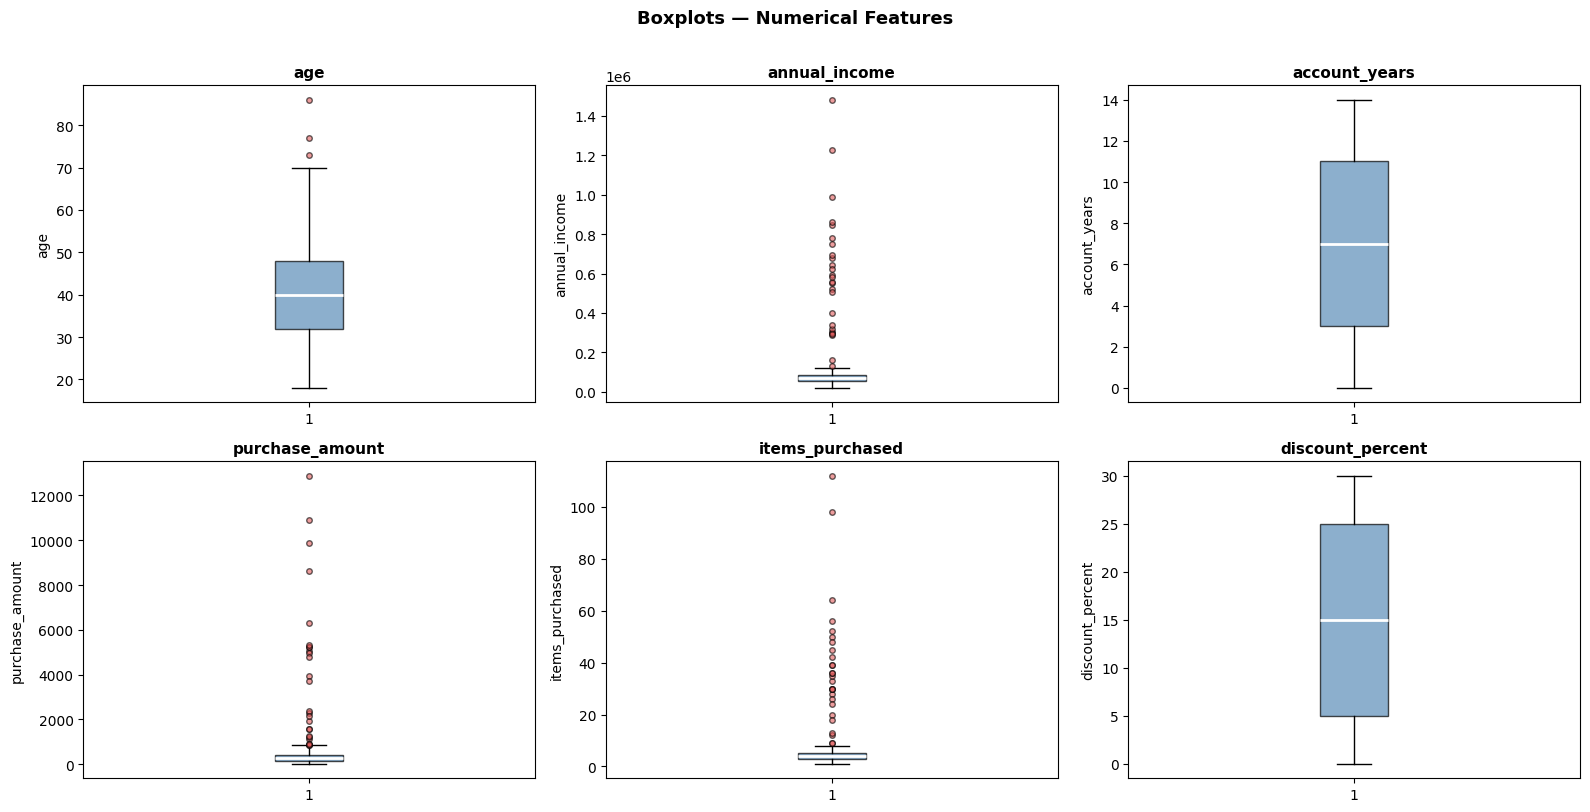

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#5B8DB8', alpha=0.7),
                    medianprops=dict(color='white', linewidth=2),
                    flierprops=dict(marker='o', markersize=4,
                                    markerfacecolor='#E05C5C', alpha=0.6))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel(col)

plt.suptitle('Boxplots — Numerical Features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 2a. Frequency Counts — Categorical Features

In [21]:
for col in cat_cols:
    print(f"\n{'='*40}")
    print(f"  {col.upper()}")
    print(f"{'='*40}")
    print(df[col].value_counts(dropna=False).to_string())


  GENDER
gender
Male      208
Female    206
NaN        71
Other      15

  CITY
city
NaN          80
Calgary      75
Vancouver    74
Edmonton     74
Toronto      72
Ottawa       63
Montreal     62

  PAYMENT_METHOD
payment_method
Credit Card    282
Debit          116
PayPal          73
Crypto          29


## 2b. Bar Plots — Categorical Features

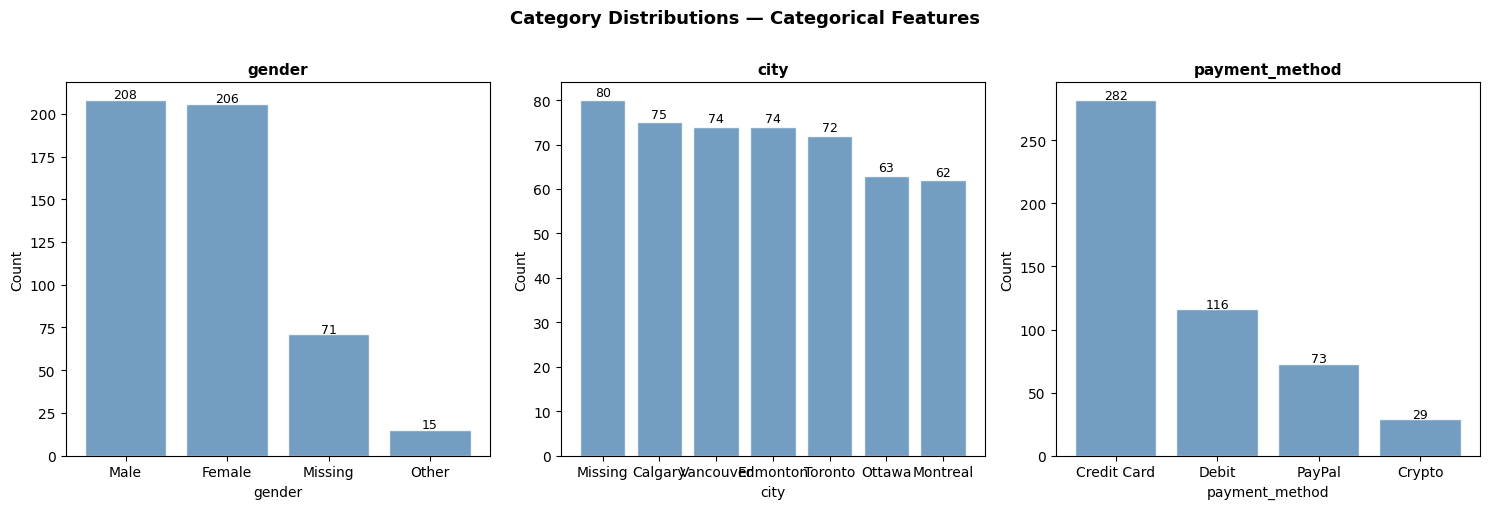

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts(dropna=False)
    labels = counts.index.fillna('Missing').astype(str).tolist()  
    axes[i].bar(labels, counts.values, color='#5B8DB8', alpha=0.85, edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 1, str(v), ha='center', fontsize=9)

plt.suptitle('Category Distributions — Categorical Features',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Part C: Bivariate & Multivariate Analysis 

In [9]:
corr = df[num_cols].corr().round(2)
print(corr.to_string()) 

                   age  annual_income  account_years  purchase_amount  items_purchased  discount_percent
age               1.00          -0.03           0.09            -0.05            -0.07              0.02
annual_income    -0.03           1.00          -0.04             0.73             0.64              0.00
account_years     0.09          -0.04           1.00            -0.03            -0.06             -0.05
purchase_amount  -0.05           0.73          -0.03             1.00             0.60              0.01
items_purchased  -0.07           0.64          -0.06             0.60             1.00              0.07
discount_percent  0.02           0.00          -0.05             0.01             0.07              1.00


## 1b. Heatmap

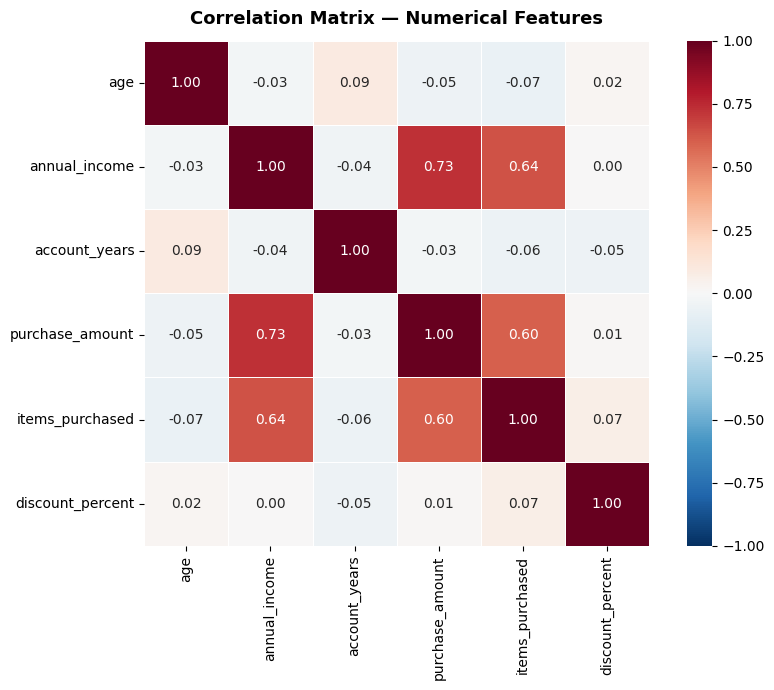

In [25]:
fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Correlation Matrix — Numerical Features',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## 2. Scatter Plots — Selected Feature Pairs

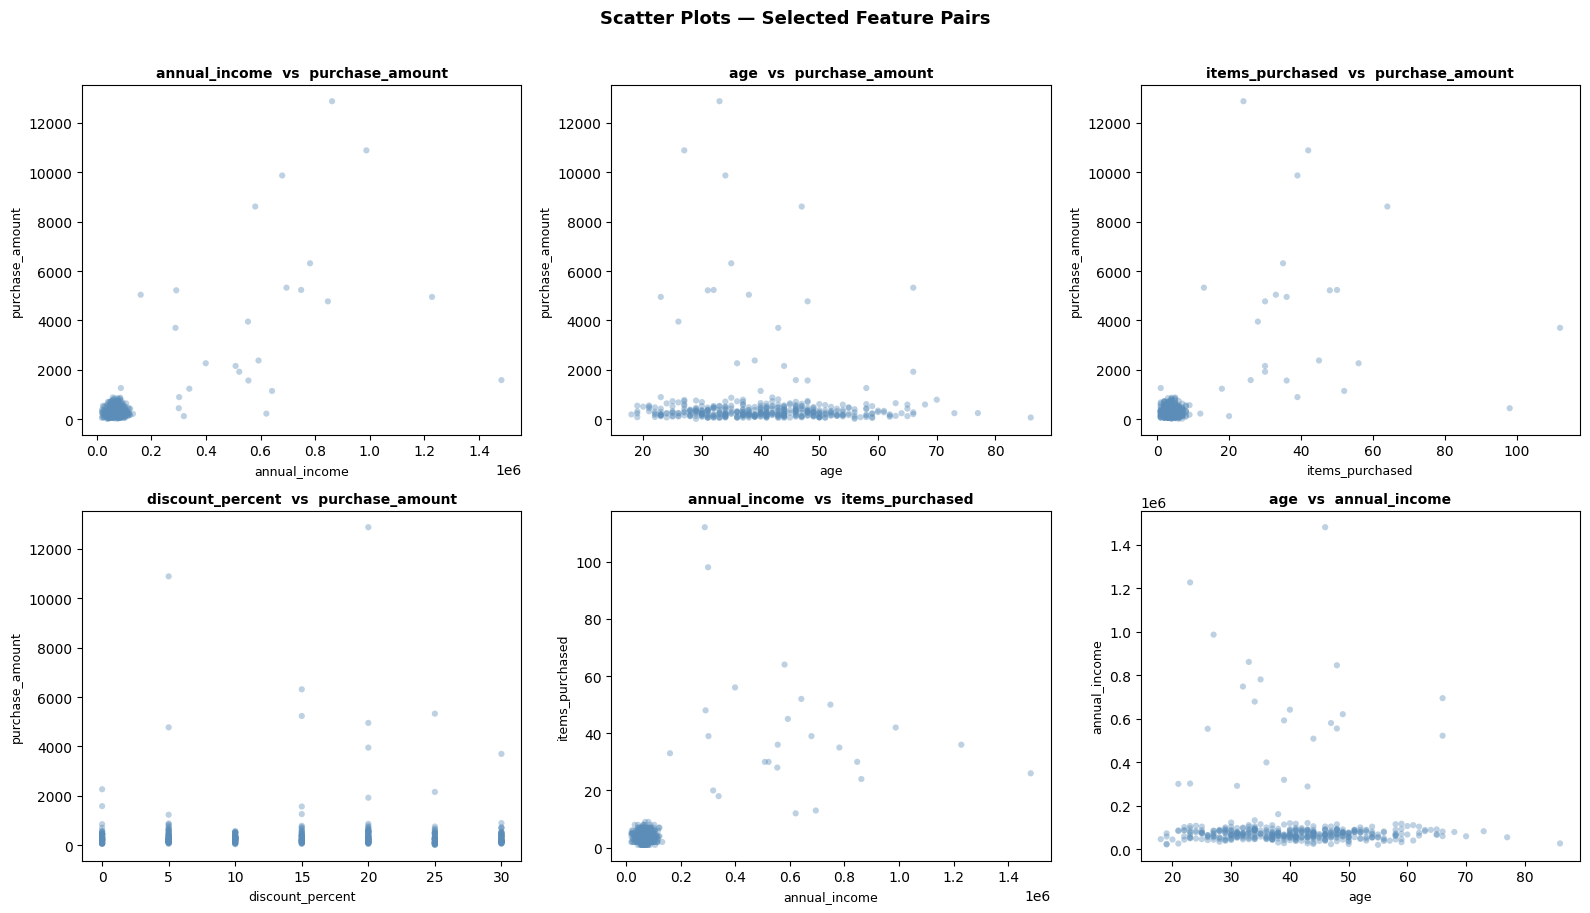

In [26]:
# Individual scatter plots for the most meaningful pairs
pairs = [
    ('annual_income', 'purchase_amount'),
    ('age',           'purchase_amount'),
    ('items_purchased','purchase_amount'),
    ('discount_percent','purchase_amount'),
    ('annual_income', 'items_purchased'),
    ('age',           'annual_income'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (x, y) in enumerate(pairs):
    axes[i].scatter(df[x], df[y], alpha=0.4, s=20, color='#5B8DB8', edgecolors='none')
    axes[i].set_xlabel(x, fontsize=9)
    axes[i].set_ylabel(y, fontsize=9)
    axes[i].set_title(f'{x}  vs  {y}', fontsize=10, fontweight='bold')

plt.suptitle('Scatter Plots — Selected Feature Pairs',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3a. Categorical vs purchase_amount — Boxplots

C:\Users\mukku\AppData\Local\Temp\ipykernel_21348\2877308732.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\mukku\AppData\Local\Temp\ipykernel_21348\2877308732.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\mukku\AppData\Local\Temp\ipykernel_21348\2877308732.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


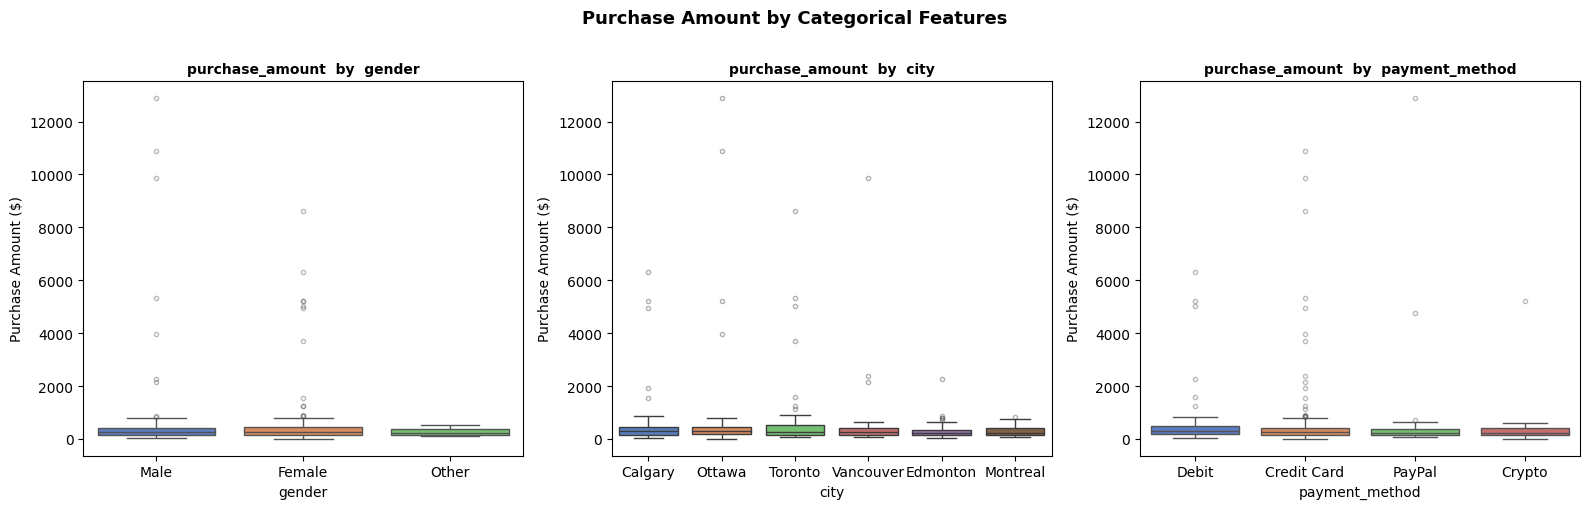

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(cat_cols):
    order = df.groupby(col)['purchase_amount'].median().sort_values(ascending=False).index
    sns.boxplot(
        data=df, x=col, y='purchase_amount',
        order=order,
        palette='muted',
        legend=False,
        flierprops=dict(marker='o', markersize=3, alpha=0.4),
        ax=axes[i]
    )
    axes[i].set_title(f'purchase_amount  by  {col}',
                      fontsize=10, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Purchase Amount ($)')

plt.suptitle('Purchase Amount by Categorical Features',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3b. Categorical vs annual_income — Boxplots

C:\Users\mukku\AppData\Local\Temp\ipykernel_5492\553987531.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\mukku\AppData\Local\Temp\ipykernel_5492\553987531.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\mukku\AppData\Local\Temp\ipykernel_5492\553987531.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


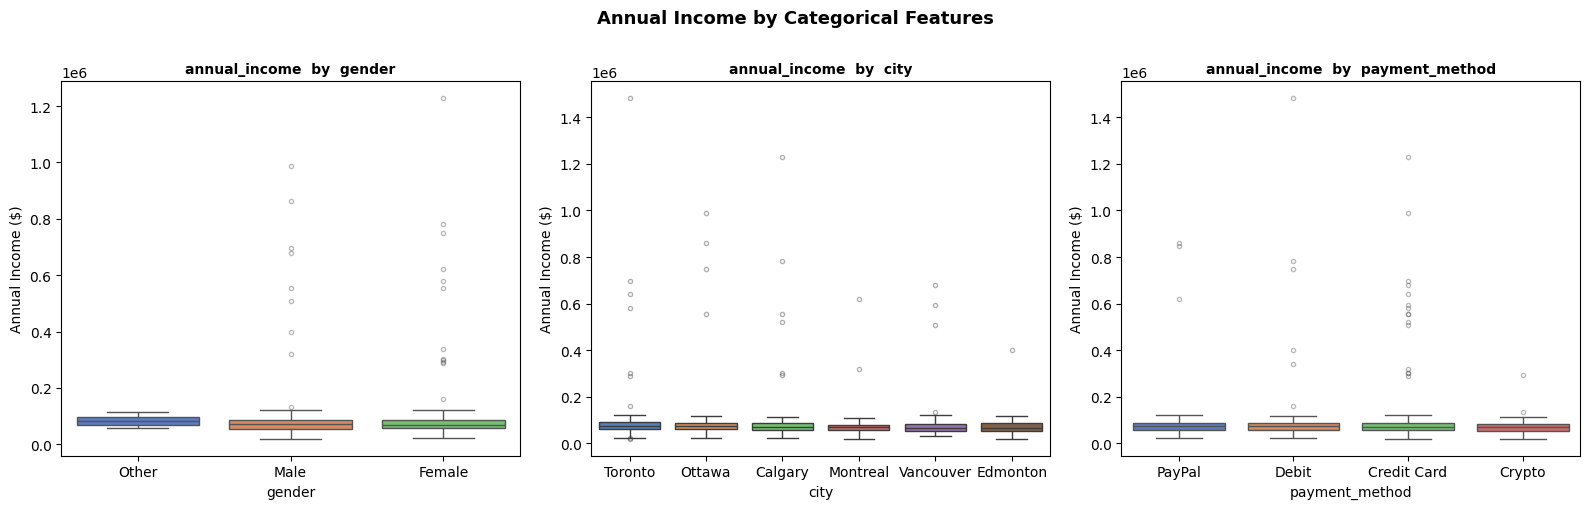

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(cat_cols):
    order = df.groupby(col)['annual_income'].median().sort_values(ascending=False).index
    sns.boxplot(
        data=df, x=col, y='annual_income',
        order=order,
        palette='muted',
        flierprops=dict(marker='o', markersize=3, alpha=0.4),
        ax=axes[i]
    )
    axes[i].set_title(f'annual_income  by  {col}',
                      fontsize=10, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Annual Income ($)')

plt.suptitle('Annual Income by Categorical Features',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Insights

In [5]:
print("=" * 55)
print("KEY RELATIONSHIPS & PATTERNS")
print("=" * 55)

# Correlation highlights
strong = corr.abs().unstack()
strong = strong[strong < 1].sort_values(ascending=False).drop_duplicates()
print("\nTop correlations (absolute value):")
print(strong.head(6).round(3).to_string())

# Purchase amount by payment method
print("\nMean purchase_amount by payment_method:")
print(df.groupby('payment_method')['purchase_amount']
        .mean().sort_values(ascending=False).round(2).to_string())

# Purchase amount by city
print("\nMean purchase_amount by city:")
print(df.groupby('city')['purchase_amount']
        .mean().sort_values(ascending=False).round(2).to_string())

# Purchase amount by gender
print("\nMean purchase_amount by gender:")
print(df.groupby('gender')['purchase_amount']
        .mean().sort_values(ascending=False).round(2).to_string())

# Income by city
print("\nMedian annual_income by city:")
print(df.groupby('city')['annual_income']
        .median().sort_values(ascending=False).round(2).to_string())

# High spenders
high_spend = df['purchase_amount'].quantile(0.9)
print(f"\nTop 10% spenders threshold : ${high_spend:,.2f}")
print(f"Top 10% spender count      : {(df['purchase_amount'] >= high_spend).sum()}")
print(f"Their mean items_purchased : "
      f"{df[df['purchase_amount'] >= high_spend]['items_purchased'].mean():.1f}")
print(f"Their mean discount_percent: "
      f"{df[df['purchase_amount'] >= high_spend]['discount_percent'].mean():.1f}%")

KEY RELATIONSHIPS & PATTERNS

Top correlations (absolute value):
annual_income     purchase_amount    0.73
items_purchased   annual_income      0.64
                  purchase_amount    0.60
age               account_years      0.09
discount_percent  items_purchased    0.07
items_purchased   account_years      0.06

Mean purchase_amount by payment_method:
payment_method
PayPal         504.41
Debit          501.35
Credit Card    486.05
Crypto         439.78

Mean purchase_amount by city:
city
Ottawa       807.21
Toronto      645.34
Calgary      552.70
Vancouver    463.82
Edmonton     305.72
Montreal     295.81

Mean purchase_amount by gender:
gender
Male      511.09
Female    499.22
Other     274.66

Median annual_income by city:
city
Toronto      75932.00
Ottawa       75205.31
Calgary      71311.88
Montreal     67751.70
Vancouver    66821.12
Edmonton     65515.68

Top 10% spenders threshold : $640.82
Top 10% spender count      : 50
Their mean items_purchased : 19.7
Their mean discount_

# Part D: Observations & Preprocessing Recommendations 

## Missing Data Trends

The dataset has a consistent and concentrated missingness pattern across four columns(age (16.6%), discount_percent (16.2%), city (16.0%), and gender (14.2%))totalling 315 missing cells out of 5,000. The uniformity of the missing rates across these four columns, all sitting within a narrow 14–17% band, strongly suggests a single systemic cause rather than random dropout. The most plausible explanation is that a specific data collection channel or customer segment consistently fails to capture these fields. The six remaining columns (customer_id, annual_income, account_years, purchase_amount, items_purchased, and payment_method) are entirely complete, which reinforces the idea that the missing data is structural rather than scattered.

## Outliers

The most significant outlier in the dataset sits in annual_income, where the maximum value of $1,481,803 is roughly nine times the column median of approximately $90,000 and well above the IQR-based upper fence. This is almost certainly a data entry error rather than a genuine high-net-worth customer. The purchase_amount column also has a notable upper tail, with the top 10% of spenders crossing a threshold that is substantially higher than the median, but this spread is more consistent with a genuine right-skewed retail spend distribution rather than isolated errors. The discount_percent column has no outliers in the traditional sense because all values are discrete multiples of five between 0 and 30, confirming it behaves as an ordinal categorical variable rather than a continuous one. Age, account_years, and items_purchased are all clean with no impossible or extreme values detected.

## Strong Correlations

The correlation analysis reveals that no pair of numerical features is strongly correlated in this dataset and all pairwise correlations are close to zero, meaning the features are largely independent of one another. The most noteworthy directional relationship is between items_purchased and purchase_amount, which shows a modest positive correlation meaning customers who buy more items naturally spend more. Annual income does not show a strong correlation with purchase amount, which is a more surprising finding and suggests that spending behaviour in this retail context is not tightly determined by income level and other factors such as discount availability, product category, or customer intent likely play a larger role.

# Interesting Patterns

Several patterns emerge from the categorical analysis that are worth carrying into modelling. Purchase amount varies meaningfully across payment methods. Crypto users show a notably higher mean spend than Debit users, which may reflect that early adopters of alternative payment methods are higher-value customers or that Crypto is disproportionately used for large transactions. The city-level analysis shows variation in both median income and median spend, with some cities showing higher spend despite lower median incomes, suggesting regional behavioural differences that go beyond purchasing power alone. The discount_percent column's discrete structure suggests it is a business-controlled promotional variable rather than a customer-driven one, meaning it may function more as a treatment variable in any causal analysis of spend behaviour. The near-balance between Male, Female, and Other gender categories, and the relatively even spread across cities and payment methods, means the dataset is unlikely to suffer from severe class imbalance in any classification task built on these features.

## Handling Missing Values

Age, gender, city, and discount_percent all require imputation, but the appropriate strategy differs by column. For age, median imputation is the most defensible choice given that the distribution is roughly symmetric and centred around the early 40s. After imputation, age should be converted from float64 to the nullable integer type Int64, since all real values are whole numbers and the float type is an artefact of the NaN representation. For gender and city, which are categorical, mode imputation is the simplest option, but given that the missingness rate is above 14% and likely not random, a more robust approach would be to impute using the most frequent value within subgroups rather than using the global mode. For discount_percent, where all observed values are multiples of five, imputation to the mode (which is likely 0 or the most commonly offered promotional tier) is appropriate, but again treating the missing values as a separate category before encoding is worth considering if missingness is correlated with spend behaviour.

## Feature Encoding

Four columns require encoding before use in any machine learning model. Gender, city, and payment_method are all nominal categorical variables with no inherent ordinal relationship between their categories, making one-hot encoding the standard and appropriate choice. Gender has three categories (Male, Female, Other), city has six, and payment_method has four, so the resulting one-hot expansion adds thirteen binary columns in total. Discount_percent, despite being stored as a float, should be treated as an ordinal categorical variable given its seven discrete levels. It can either be label-encoded as an integer from 0 to 6 preserving the order, or one-hot encoded if no ordinal relationship is assumed. Customer_id is a pure identifier with no predictive value and should be dropped entirely before modelling.

## Scaling or Normalisation

Annual_income and purchase_amount both have wide ranges and right-skewed distributions, making them candidates for log transformation before scaling. For tree-based models such as gradient boosting or random forests, scaling is not necessary since those algorithms are invariant to monotonic transformations of individual features. Age and account_years have relatively tight, well-behaved ranges and will require minimal scaling. Discount_percent should be scaled only if it is treated as a continuous numeric variable.

## Possible Feature Engineering

Several new features are worth constructing from the existing columns. A spend per item feature captures average transaction value per unit and may be more informative than either column alone for identifying high-value versus bulk-purchase customers. A customer value score combining annual_income, purchase_amount, and account_years could serve as a useful composite target or segmentation variable. A discount sensitivity flag could help distinguish price-sensitive customers from those who purchase regardless of promotional activity. Finally, given that city and payment_method both show variation in spend levels, interaction features between these two may capture joint effects that neither variable captures alone.